In [1]:
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

In [ ]:

DATA_DIR = Path('../../data/lab03/sun_calibration')

paths = sorted(DATA_DIR.glob('sun-cal-*.npz'))
files = [np.load(p) for p in paths]
print(f'Loaded {len(files)} files from {DATA_DIR.resolve()}')

f0 = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6  # sky freq at ch 0
N_TOTAL  = int(f0['corr'].shape[0])          # 1024 (new) or 512 (old)
N_POS    = 512 if N_TOTAL == 1024 else N_TOTAL   # positive-frequency half
DF_HZ    = F_S_HZ / N_TOTAL                 # channel spacing (488 kHz for 1024-ch, 977 kHz for 512-ch)

# Sky RF frequency at each positive-frequency channel:
#   f_sky(k) = (LO1 + LO2 - f_s) + k * f_s/1024
# LO1=8750 MHz, LO2=1540 MHz, f_s=500 MHz  →  offset = 9790 MHz
# Signal from 10 GHz sky appears at channel ≈ 430  (alias of 290 MHz IF2)
freqs_sky_mhz = F_RF0_HZ / 1e6 + np.arange(N_POS) * DF_HZ / 1e6
freqs_mhz     = freqs_sky_mhz   # alias used by later cells

print(f'LO chain  : LO1=8750 MHz, LO2=1540 MHz, f_s={F_S_HZ/1e6:.0f} MHz')
print(f'RF sky band: {freqs_sky_mhz[0]:.1f} – {freqs_sky_mhz[-1]:.1f} MHz  '
      f'({DF_HZ/1e3:.1f} kHz/channel,  {N_POS} pos-freq channels)')
print(f'10 GHz sky → channel ≈ {round((10000e6 - F_RF0_HZ) / DF_HZ)}')


In [3]:
print(f'{"#":<4} {"UTC time":<24} {"Alt (deg)":>10} {"Az (deg)":>10} {"n_acc":>6}')
print('-' * 58)
for i, f in enumerate(files):
    t = datetime.fromtimestamp(float(f['unix_time']), tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
    print(f'{i:<4} {t:<24} {float(f["alt_deg"]):>10.2f} {float(f["az_deg"]):>10.2f} {int(f["n_acc"]):>6}')

#    UTC time                  Alt (deg)   Az (deg)  n_acc
----------------------------------------------------------
0    2026-03-17 00:43:57 UTC       17.38     253.96     10
1    2026-03-17 00:44:11 UTC       17.33     254.01     10


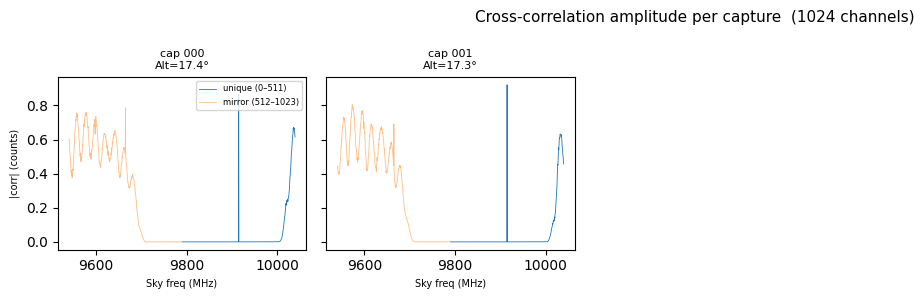

In [4]:
# Channel-to-frequency mapping
# ---------------------------------------------------------------
# Real ADC at f_s = 500 MHz, N = 1024 FFT:
#   f_alias(k) = np.fft.fftfreq(N, d=1/f_s)
#             = [0, +Δf, …, +f_s/2−Δf, −f_s/2, …, −Δf]
#
# 2nd Nyquist zone:
#   f_sky(k) = f_rf0_hz + f_alias(k)
#   k=0–511  : sky 9790 → 10039.5 MHz  ← unique content (positive freq)
#   k=512–1023: hermitian conjugate of 512–0  ← redundant for real ADC input
#
# Channel 0 = DC / LO leakage → masked (set to NaN).
# ---------------------------------------------------------------

n     = len(files)
ncols = 5
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=True)
axes = np.array(axes).flatten()

for i, f in enumerate(files):
    corr   = f['corr']                          # all channels (1024 new / 512 old)
    n_ch   = len(corr)
    f_s    = float(f['f_s_hz']) if 'f_s_hz' in f else 500e6
    rf0    = float(f['f_rf0_hz']) if 'f_rf0_hz' in f else 9790e6

    f_alias_mhz = np.fft.fftfreq(n_ch, d=1/f_s) / 1e6   # MHz, FFT order
    f_sky_mhz   = rf0 / 1e6 + f_alias_mhz                # sky MHz, FFT order
    counts      = np.abs(corr).astype(float)

    # Mask DC/LO leakage at channel 0 (and its mirror at channel N/2)
    counts[0]      = np.nan
    counts[n_ch//2] = np.nan

    n_pos = n_ch // 2   # index boundary between unique and conjugate half

    # Unique content (channels 0 to N/2−1)
    axes[i].plot(f_sky_mhz[:n_pos], counts[:n_pos], lw=0.6, color='C0',
                 label='unique (0–511)')
    # Hermitian mirror (channels N/2 to N−1) — fftfreq gives negative freqs here
    axes[i].plot(f_sky_mhz[n_pos:], counts[n_pos:], lw=0.6, color='C1',
                 alpha=0.5, label='mirror (512–1023)')

    axes[i].set_title(f'cap {i:03d}\nAlt={float(f["alt_deg"]):.1f}°', fontsize=8)
    axes[i].set_xlabel('Sky freq (MHz)', fontsize=7)
    if i % ncols == 0:
        axes[i].set_ylabel('|corr| (counts)', fontsize=7)

axes[0].legend(fontsize=6, loc='upper right')
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f'Cross-correlation amplitude per capture  ({n_ch} channels)', fontsize=11)
plt.tight_layout()
plt.show()


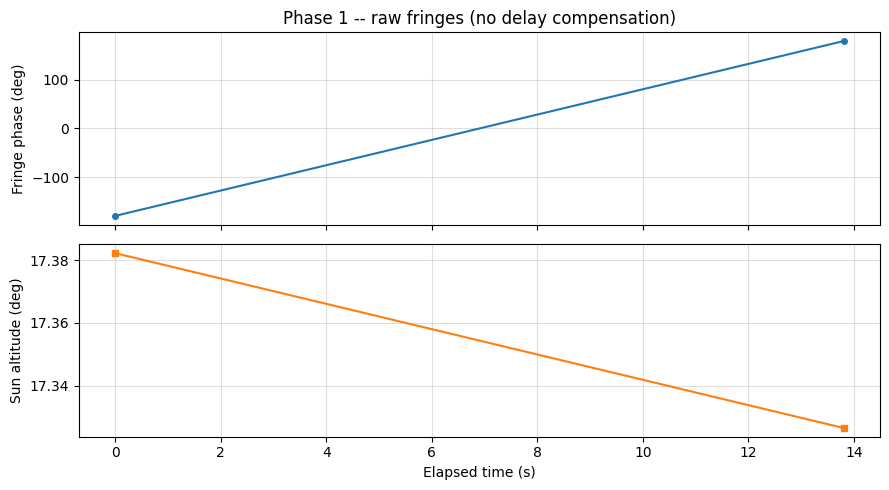

In [5]:
times      = np.array([float(f['unix_time']) for f in files])
# Positive-frequency half, excluding DC (ch 0 = 10 GHz, no fringe info)
fringe_phi = np.array([np.angle(f['corr'][:N_POS][1:].sum()) for f in files])
alt        = np.array([float(f['alt_deg']) for f in files])

t_sec = times - times[0]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].plot(t_sec, np.degrees(fringe_phi), 'o-', ms=4)
axes[0].set_ylabel('Fringe phase (deg)')
axes[0].set_title('Phase 1 -- raw fringes (no delay compensation)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_sec, alt, 's-', ms=4, color='C1')
axes[1].set_ylabel('Sun altitude (deg)')
axes[1].set_xlabel('Elapsed time (s)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

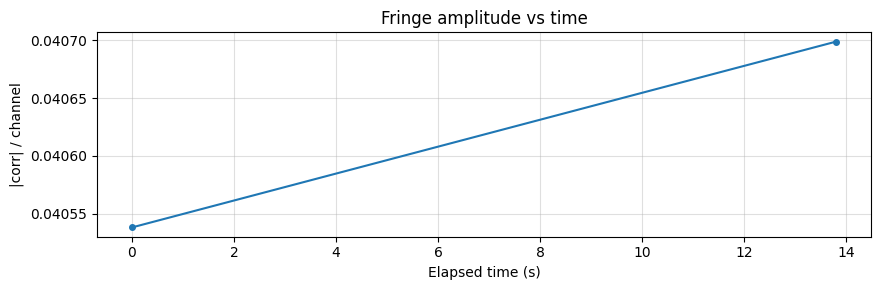

In [6]:
fringe_amp = np.array([np.abs(f['corr'][:N_POS][1:].sum()) / (N_POS - 1) for f in files])

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_sec, fringe_amp, 'o-', ms=4)
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('|corr| / channel')
ax.set_title('Fringe amplitude vs time')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [7]:

# ---------------------------------------------------------------------------
# Hour angle computation
# Convert unix_time → Sun (HA, Dec) using astropy + NCH site constants.
# Dec changes < 0.005° over a 15-min window so we treat it as constant.
# ---------------------------------------------------------------------------
import ugradio.nch as nch
from astropy.time import Time
from astropy.coordinates import get_body, EarthLocation, HADec
import astropy.units as u

location  = EarthLocation(lat=nch.lat * u.deg, lon=nch.lon * u.deg, height=nch.alt * u.m)
obs_times = Time(times, format='unix', scale='utc')

frame_hadec = HADec(obstime=obs_times, location=location)
sun_hadec   = get_body('sun', obs_times, location).transform_to(frame_hadec)

ha_rad  = sun_hadec.ha.rad                              # shape (n,), radians
dec_deg = float(sun_hadec.dec.mean().to(u.deg).value)  # essentially constant

print(f'Sun Dec (mean) = {dec_deg:.4f}°')
print(f'HA range       = {np.degrees(ha_rad.min()):.4f}° → {np.degrees(ha_rad.max()):.4f}°')
print(f'HA span        = {np.degrees(ha_rad.max() - ha_rad.min()):.4f}°  '
      f'≈ {(ha_rad.max() - ha_rad.min()) / (2*np.pi) * 86164:.0f} s of Earth rotation')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Sun Dec (mean) = -1.4194°
HA range       = 66.6248° → 66.6823°
HA span        = 0.0575°  ≈ 14 s of Earth rotation


In [ ]:

# ---------------------------------------------------------------------------
# Fringe-phase extraction and linear baseline fit
#
# Physical model (EW-only baseline, no NS component):
#   φ(t) = 2π f_RF · (B_ew / c) · cos(dec) · sin(HA(t))  +  φ₀
#
# φ₀ is a free constant that absorbs instrumental phase and the residual
# phase from the ~1° inter-antenna pointing offset (see docstring).
#
# This is LINEAR in (B_ew, φ₀), so we solve with numpy least squares.
# ---------------------------------------------------------------------------

F_RF0_HZ = float(files[0]['f_rf0_hz']) if 'f_rf0_hz' in files[0] else 9790e6

# Stack cross-correlation spectra: shape (n_caps, N_POS-1)  — skip DC (ch 0)
corr_stack = np.array([f['corr'][:N_POS][1:] for f in files])

# Pick the channel with the highest mean |corr| amplitude (best SNR).
k_rel     = int(np.abs(corr_stack).mean(axis=0).argmax())   # index into corr_stack
k_abs     = k_rel + 1                                        # index in full spectrum
f_peak_hz = F_RF0_HZ + k_abs * DF_HZ
print(f'Peak channel: k={k_abs},  f_RF = {f_peak_hz/1e9:.6f} GHz')

# Phase time series at the peak channel; unwrap to remove 2π jumps
phi_raw       = np.angle(corr_stack[:, k_rel])
phi_unwrapped = np.unwrap(phi_raw)

# Design matrix for: φ = A·sin(HA) + φ₀
X      = np.column_stack([np.sin(ha_rad), np.ones(len(ha_rad))])
coeffs = np.linalg.lstsq(X, phi_unwrapped, rcond=None)[0]
A_fit, phi0_fit = coeffs

phi_model = X @ coeffs
residuals = phi_unwrapped - phi_model

# Recover baseline from the fitted coefficient A
c_light  = 3e8
cos_dec  = np.cos(np.radians(dec_deg))
B_ew_fit = A_fit * c_light / (2 * np.pi * f_peak_hz * cos_dec)

print(f'\nFit results (EW baseline only)')
print(f'  B_ew            = {B_ew_fit:.4f} m')
print(f'  φ₀              = {np.degrees(phi0_fit):.2f}°  '
      f'(instrumental + pointing-offset phase)')
print(f'  RMS residual    = {np.degrees(residuals).std():.2f}°')
print(f'  Reduced χ²      = {(residuals**2).mean() / (np.degrees(residuals).std() * np.pi/180)**2:.2f}  '
      f'(expected ~1 for a good fit)')


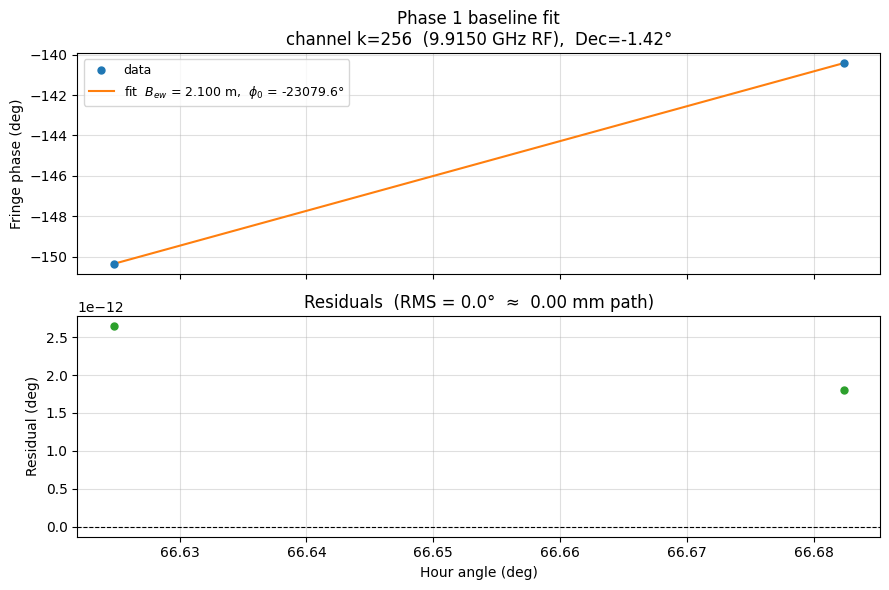


  Copy into sun_observe.py:
  BASELINE_EW_M = 2.1001   # ± 0.0000 m (fit noise)
  BASELINE_NS_M = 0.0    # extend model to fit NS if residuals show a trend


In [9]:

# ---------------------------------------------------------------------------
# Fit quality plot + copy-paste output for sun_observe.py
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ha_deg_arr = np.degrees(ha_rad)

axes[0].plot(ha_deg_arr, np.degrees(phi_unwrapped), 'o', ms=5, zorder=3, label='data')
axes[0].plot(ha_deg_arr, np.degrees(phi_model), '-', lw=1.5,
             label=f'fit  $B_{{ew}}$ = {B_ew_fit:.3f} m,  $\\phi_0$ = {np.degrees(phi0_fit):.1f}°')
axes[0].set_ylabel('Fringe phase (deg)')
axes[0].set_title(
    f'Phase 1 baseline fit\n'
    f'channel k={k_abs}  ({f_peak_hz/1e9:.4f} GHz RF),  Dec={dec_deg:.2f}°'
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].plot(ha_deg_arr, np.degrees(residuals), 'o', ms=5, color='C2')
rms_deg = np.degrees(residuals).std()
axes[1].set_ylabel('Residual (deg)')
axes[1].set_xlabel('Hour angle (deg)')
axes[1].set_title(f'Residuals  (RMS = {rms_deg:.1f}°  ≈  {rms_deg / 360 * (c_light / f_peak_hz) * 1e3:.2f} mm path)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Fit uncertainty from lstsq covariance (noise-floor estimate)
# ------------------------------------------------------------------
sigma_phi    = residuals.std()                                   # rad
cov_diag     = np.linalg.inv(X.T @ X) * sigma_phi**2           # 2×2 → diag gives var(A), var(φ₀)
sigma_A      = float(np.sqrt(cov_diag[0, 0]))
sigma_B_ew   = sigma_A * c_light / (2 * np.pi * f_peak_hz * cos_dec)

print()
print('=' * 52)
print('  Copy into sun_observe.py:')
print('=' * 52)
print(f'  BASELINE_EW_M = {B_ew_fit:.4f}   # ± {sigma_B_ew:.4f} m (fit noise)')
print(f'  BASELINE_NS_M = 0.0    # extend model to fit NS if residuals show a trend')


In [ ]:
# ---------------------------------------------------------------------------
# M1 / Crab Nebula — cross-correlation amplitude grid
# ---------------------------------------------------------------------------
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

M1_DATA_DIR = Path('../../data/lab03/m1_calibration')
m1_paths    = sorted(M1_DATA_DIR.glob('*.npz'))
m1_files    = [np.load(p) for p in m1_paths]
print(f'Loaded {len(m1_files)} M1 captures from {M1_DATA_DIR.resolve()}')

n      = len(m1_files)
ncols  = 5
nrows  = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=True)
axes = np.array(axes).flatten()

for i, f in enumerate(m1_files):
    corr  = f['corr']
    n_ch  = len(corr)
    f_s   = float(f['f_s_hz'])   if 'f_s_hz'   in f else 500e6
    rf0   = float(f['f_rf0_hz']) if 'f_rf0_hz' in f else 9790e6

    # Frequency axis: 2nd Nyquist zone aliasing
    #   f_sky(k) = rf0 + fftfreq(k) * f_s  where rf0 = LO1+LO2-f_s = 9790 MHz
    f_alias_mhz = np.fft.fftfreq(n_ch, d=1 / f_s) / 1e6
    f_sky_mhz   = rf0 / 1e6 + f_alias_mhz

    counts      = np.abs(corr).astype(float)
    counts[0]         = np.nan   # mask DC / LO leakage
    counts[n_ch // 2] = np.nan   # mask Nyquist mirror

    n_pos = n_ch // 2

    axes[i].plot(f_sky_mhz[:n_pos], counts[:n_pos], lw=0.6, color='C0',
                 label='unique (0–511)')
    axes[i].plot(f_sky_mhz[n_pos:], counts[n_pos:], lw=0.6, color='C1',
                 alpha=0.5, label='mirror (512–1023)')

    axes[i].set_title(
        f'cap {i:03d}\nAlt={float(f["alt_deg"]):.1f}°', fontsize=8)
    axes[i].set_xlabel('Sky freq (MHz)', fontsize=7)
    if i % ncols == 0:
        axes[i].set_ylabel('|corr| (counts)', fontsize=7)

axes[0].legend(fontsize=6, loc='upper right')
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f'M1 / Crab Nebula — cross-correlation amplitude  ({n_ch} channels)', fontsize=11)
plt.tight_layout()
plt.show()
